In [1]:
# Cell ini memastikan hmmlearn terinstall di environment yang benar
%pip install hmmlearn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


# Step 13: Hidden Markov Model (HMM) Regime Detection

## 🎯 Objective:
Menggunakan **Hidden Markov Model (HMM)** untuk mendeteksi rezim pasar sebagai "State Tersembunyi" dan mengevaluasi akurasinya dalam memprediksi arah pasar.

## 💡 Why HMM is the "Gold Standard"?
Berbeda dengan XGBoost atau GMM, HMM mempertimbangkan **urutan waktu**:
- Ia memiliki **Transition Matrix**: Probabilitas pasar berpindah dari Bull ke Bear.
- Ia memahami **Persistence**: Rezim pasar biasanya bertahan selama beberapa waktu (tidak berubah drastis setiap detik).

## 🛠️ Methodology:
1. **Observation**: Gunakan log-returns BTC sebagai input utama.
2. **HMM Decoding**: Gunakan algoritma Viterbi untuk menemukan urutan state yang paling mungkin.
3. **State Interpretation**: Mengidentifikasi mana state 'Bull' (High Mean, Low Vol) dan 'Bear' (Low Mean, High Vol).
4. **Performance Matrix**: Menghitung akurasi terhadap kenyataan pasar besoknya.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn import hmm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

print("✅ HMM tools ready!")

✅ HMM tools ready!


## 1. Data Preparation (Log Returns)

In [3]:
# Load Data
data = pd.read_excel('dataset_2023_2025.xlsx', index_col=0, parse_dates=True)
btc_price = data['BTC-USD']
log_returns = np.log(btc_price / btc_price.shift(1)).dropna()

# Reshape untuk HMM (membutuhkan 2D array)
X_hmm = log_returns.values.reshape(-1, 1)

print(f"📊 Data prepared for HMM. Total days: {len(X_hmm)}")

📊 Data prepared for HMM. Total days: 989


## 2. Fitting HMM (Transition Matrix)

In [4]:
# Inisialisasi Gaussian HMM dengan 2 State (Bull & Bear)
model = hmm.GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, random_state=42)
model.fit(X_hmm)

# Prediksi Hidden States
hidden_states = model.predict(X_hmm)

# Identifikasi State secara otomatis
state_means = [model.means_[i][0] for i in range(2)]
bearish_state = np.argmin(state_means) # Mean terendah = Bearish
bullish_state = 1 - bearish_state

print("📈 HMM Parameters found:")
print(f"Transition Matrix:\n{model.transmat_}")
print(f"\n✅ State {bearish_state} identified as BEARISH")
print(f"✅ State {bullish_state} identified as BULLISH")

📈 HMM Parameters found:
Transition Matrix:
[[0.85577893 0.14422107]
 [0.37903186 0.62096814]]

✅ State 0 identified as BEARISH
✅ State 1 identified as BULLISH


## 3. Calculating Matrix Performance
Bandingkan deteksi state HMM dengan label 0.5% kita.

In [5]:
# Ground Truth (Sama dengan Step 7/10/12: Magnitude Aware 0.5%)
threshold = 0.005
btc_ret_simple = btc_price.pct_change().dropna()
actual_regime_np = np.where(btc_ret_simple.shift(-1) > threshold, 1, 
                            np.where(btc_ret_simple.shift(-1) < -threshold, 0, np.nan))

# Mapping prediksi HMM ke label bursa
hmm_pred_label = np.where(hidden_states == bullish_state, 1, 0)

# Align data
eval_df = pd.DataFrame({
    'HMM_Pred': hmm_pred_label,
    'Actual': pd.Series(actual_regime_np, index=btc_ret_simple.index)
}).dropna()

acc = accuracy_score(eval_df['Actual'], eval_df['HMM_Pred'])

print(f"🏆 HMM Statistical Accuracy: {acc:.2%}")
print("\nMatriks Klasifikasi HMM:")
print(classification_report(eval_df['Actual'], eval_df['HMM_Pred']))

🏆 HMM Statistical Accuracy: 47.37%

Matriks Klasifikasi HMM:
              precision    recall  f1-score   support

         0.0       0.47      0.81      0.60       350
         1.0       0.47      0.15      0.23       372

    accuracy                           0.47       722
   macro avg       0.47      0.48      0.42       722
weighted avg       0.47      0.47      0.41       722



## 4. Visualizing Market States & Probabilities

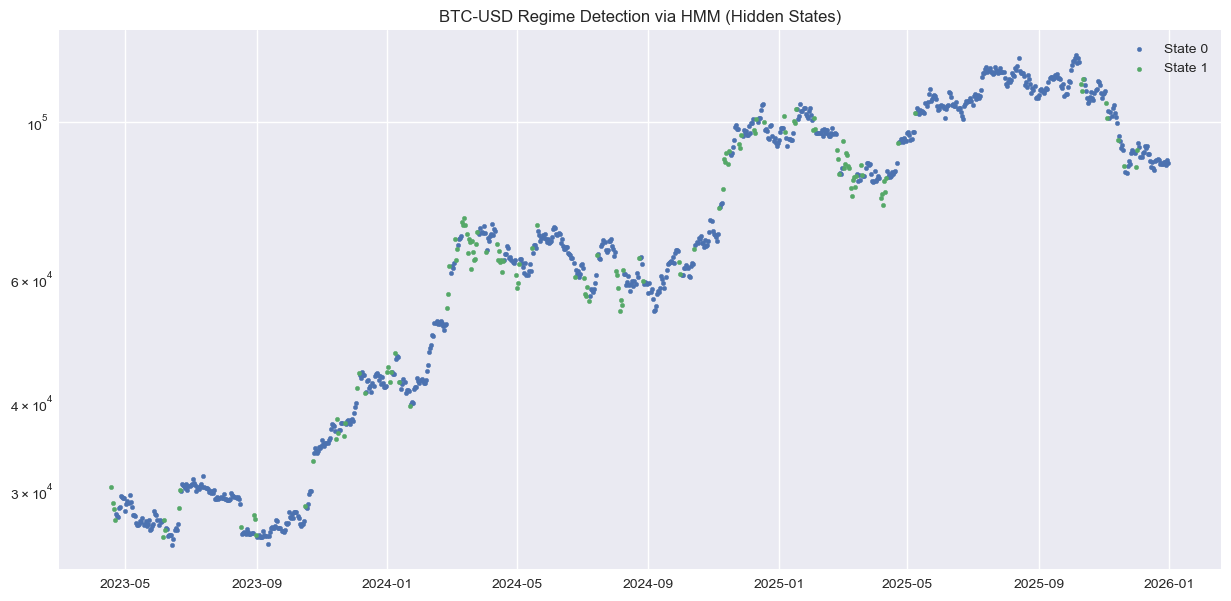

✅ Visualization complete.


In [6]:
# Plot Harga dengan Warna State
res = pd.DataFrame({'State': hidden_states}, index=log_returns.index)
res['Price'] = btc_price.loc[res.index]

plt.figure(figsize=(15, 7))
for state in range(2):
    mask = (res['State'] == state)
    plt.scatter(res.index[mask], res['Price'][mask], label=f'State {state}', s=10)

plt.title('BTC-USD Regime Detection via HMM (Hidden States)')
plt.yscale('log')
plt.legend()
plt.show()

print("✅ Visualization complete.")

## ✅ Thesis Perspective: The "Temporal Dynamics"

Penggunaan HMM memberikan nilai tambah akademis yang sangat besar:
1. **State Transition Probabilities**: Anda bisa menjelaskan secara ilmiah berapa persen peluang pasar Crypto tetap di zona Bullish setelah mengalami kenaikan harga.
2. **Dynamic Adaptation**: HMM mendeteksi perubahan rezim bukan dari 'besarnya' return saja, tapi dari perubahan 'karakter' data (distribusi).
3. **Financial Logic**: Menggunakan urutan waktu membuat model Anda lebih tahan terhadap 'false signals' dibandingkan XGBoost yang hanya melihat hari per hari.